
Two-way FE (Industry + Year) with clustered SE by Industry and year
                            OLS Regression Results                            
Dep. Variable:       Log_Output_Value   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     4900.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.77e-33
Time:                        23:43:27   Log-Likelihood:                 640.94
No. Observations:                 504   AIC:                            -1182.
Df Residuals:                     454   BIC:                            -970.7
Df Model:                          49                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


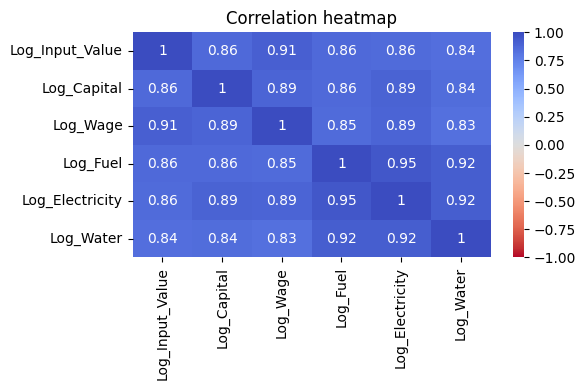

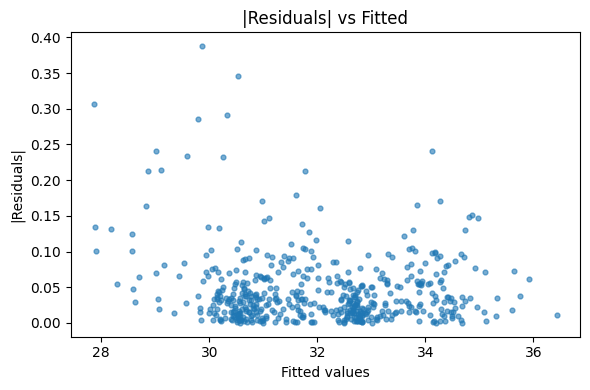

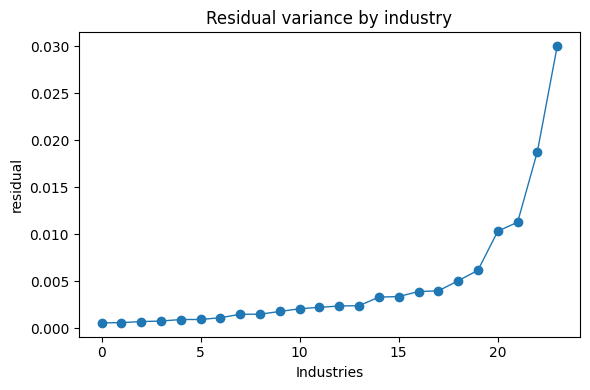

In [1]:
"""

Two-way Fixed Effects (Industry + Year) for panel data 
using cluster-robust standard errors at Industry level and year.

"""

import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor


# -----------------------------
# 0) Display / settings
# -----------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.1f}".format)

with open("../../Settings.yaml", "r") as file:
    Setting = yaml.safe_load(file)

# -----------------------------
# 1) Load data
# -----------------------------

file_path = f"{Setting['Output_Path_Ajusted']}/Adjusted.xlsx"
Dataset = pd.read_excel(file_path,sheet_name='Dataset_for_Model')

# -----------------------------
# 2) Log-transform variables
# -----------------------------

vars_to_log = ["Output_Value", "Input_Value", "Capital", "Wage", "Fuel", "Electricity", "Water"]

for c in vars_to_log:
    Dataset["Log_" + c] = np.log(Dataset[c])

# -----------------------------
# 3) Create Two-way FE design matrix:
#    - Year dummies
#    - Industry dummies
# -----------------------------

year_dum = pd.get_dummies(Dataset["Year"], prefix="Y", drop_first=True)
ind_dum  = pd.get_dummies(Dataset["Industry_Code"], prefix="I", drop_first=True)

X = pd.concat(
    [
        Dataset[[
            "Log_Input_Value", "Log_Capital", "Log_Wage",
            "Log_Fuel", "Log_Electricity", "Log_Water"
        ]],
        year_dum,
        ind_dum
    ],
    axis=1
).astype("float64")

X = sm.add_constant(X, has_constant="add")
y = Dataset["Log_Output_Value"].astype("float64")

# -----------------------------
# 4) Fit OLS + cluster-robust SE by industry and year
# -----------------------------

model= sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": Dataset[["Industry_Code","Year"]]}
)

print("\n" + "="*80)
print("Two-way FE (Industry + Year) with clustered SE by Industry and year")
print("="*80)
print(model.summary())

# -----------------------------
# 5) Heteroskedasticity diagnostic (Breusch–Pagan)
# -----------------------------
bp = het_breuschpagan(model.resid, model.model.exog)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]

print("\n" + "=" * 80)
print("Breusch–Pagan test:")
print(dict(zip(labels, bp)))
print("=" * 80)

# -----------------------------
# 6) Multicolinearity (VIF Test)
# -----------------------------
cont_cols = ["Log_Input_Value","Log_Capital","Log_Wage","Log_Fuel","Log_Electricity","Log_Water"]
X_cont = sm.add_constant(Dataset[cont_cols].astype(float))
vif = pd.DataFrame({
    "var": X_cont.columns,
    "VIF": [variance_inflation_factor(X_cont.values, i) for i in range(X_cont.shape[1])]
})
print("\n" + "=" * 80)
print("VIF test :")
print(vif.sort_values("VIF", ascending=False))
print("=" * 80)

# -----------------------------
# 7) Visual diagnostic: Multicolinearity
# -----------------------------
corr = Dataset[cont_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm_r", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Visual diagnostic: |residuals| vs fitted
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.abs(resid), s=12, alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("|Residuals|")
plt.title("|Residuals| vs Fitted")
plt.tight_layout()
plt.show()

# -----------------------------
# 9) Residual variance by industry (descriptive)
# -----------------------------
Dataset = Dataset.copy()
Dataset["resid"] = resid

var_by_ind = Dataset.groupby("Industry_Code")["resid"].var().sort_values()

plt.figure(figsize=(6, 4))
plt.plot(var_by_ind.values, marker="o", linewidth=1)
plt.xlabel("Industries")
plt.ylabel("residual")
plt.title("Residual variance by industry")
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd

# residuals
Dataset = Dataset.copy()
Dataset["resid"] = model.resid

cont_cols = ["Log_Input_Value","Log_Capital","Log_Wage","Log_Fuel","Log_Electricity","Log_Water"]

# Covariance with residuals
cov_with_resid = Dataset[cont_cols].apply(lambda x: x.cov(Dataset["resid"]))
corr_with_resid = Dataset[cont_cols].apply(lambda x: x.corr(Dataset["resid"]))

out = pd.DataFrame({
    "Cov(X, resid)": cov_with_resid,
    "Corr(X, resid)": corr_with_resid
}).sort_values("Corr(X, resid)", key=lambda s: s.abs(), ascending=False)

print(out)

                 Cov(X, resid)  Corr(X, resid)
Log_Wage                  -0.0            -0.0
Log_Capital               -0.0            -0.0
Log_Input_Value           -0.0            -0.0
Log_Electricity           -0.0            -0.0
Log_Fuel                  -0.0            -0.0
Log_Water                 -0.0            -0.0
